<a href="https://colab.research.google.com/github/Vaishnavi943/ML_Project/blob/main/HeartDisease_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Heart Disease Classifier using Regression**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("heart_sh.csv")

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.shape

(918, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

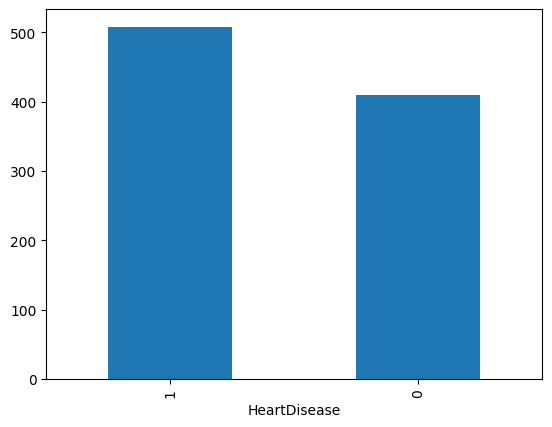

In [8]:
df['HeartDisease'].value_counts().plot(kind = 'bar')

In [9]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


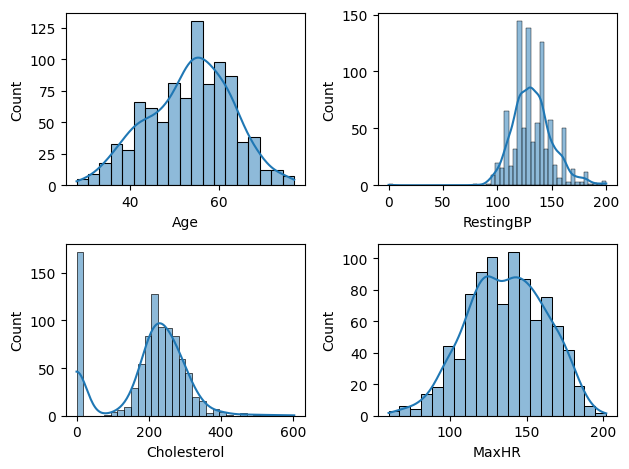

In [10]:
def ploting(var, num):
  plt.subplot(2,2,num)
  sns.histplot(df[var], kde = True)


ploting('Age', 1)
ploting('RestingBP', 2)
ploting('Cholesterol', 3)
ploting('MaxHR', 4)

plt.tight_layout()

In [11]:
# Cholesterol of a person can't be 0

ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
print(ch_mean)

244.6353887399464


In [12]:
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [13]:
# Resting BP of  person can't be 0

rest_bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0, rest_bp_mean)
df['RestingBP'] = df['RestingBP'].round(2)


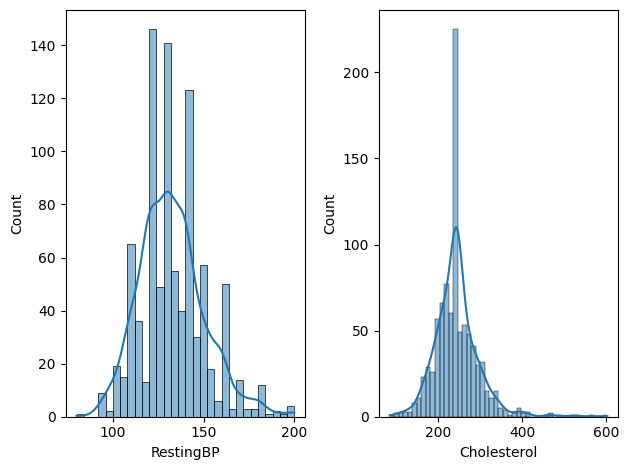

In [14]:
def ploting(var, num):
  plt.subplot(1,2,num)
  sns.histplot(df[var], kde = True)

ploting('RestingBP', 1)
ploting('Cholesterol', 2)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

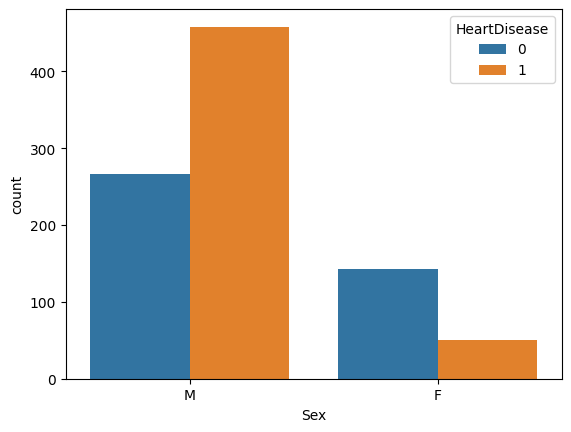

In [15]:
# categorical data -> count plot

sns.countplot(x = df['Sex'], hue=df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

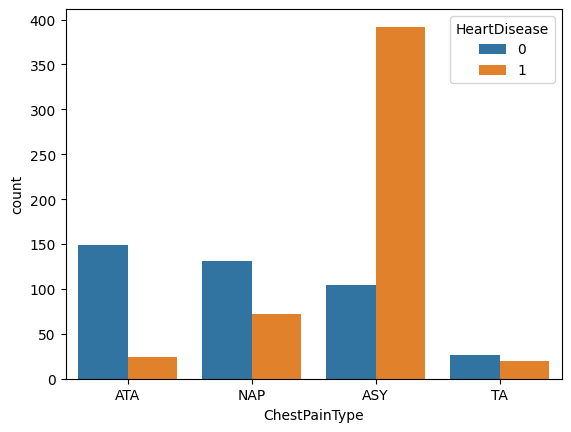

In [16]:
sns.countplot(x = df['ChestPainType'], hue  = df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

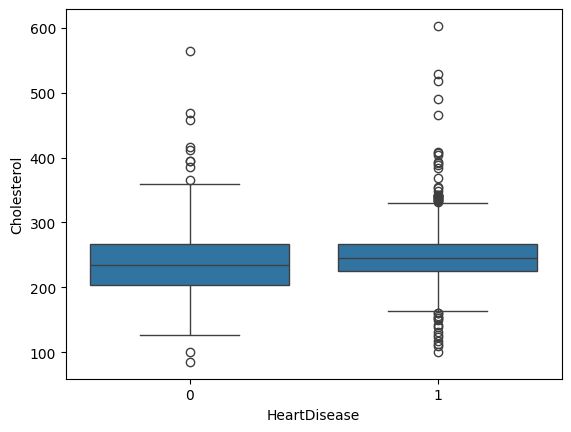

In [17]:
# box plot -> numerical var and categorical var ko compare

sns.boxplot(x = df['HeartDisease'], y = df['Cholesterol'])

<Axes: >

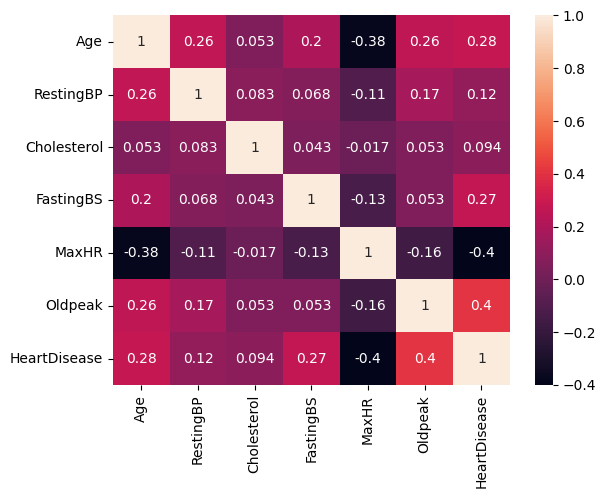

In [18]:
# heatmap -> correlation
sns.heatmap(df.corr(numeric_only=True), annot = True)

Data preprocessing and cleaning

In [19]:
df_encode = pd.get_dummies(df, drop_first = True)
print(df_encode)

     Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0     40      140.0        289.0          0    172      0.0             0   
1     49      160.0        180.0          0    156      1.0             1   
2     37      130.0        283.0          0     98      0.0             0   
3     48      138.0        214.0          0    108      1.5             1   
4     54      150.0        195.0          0    122      0.0             0   
..   ...        ...          ...        ...    ...      ...           ...   
913   45      110.0        264.0          0    132      1.2             1   
914   68      144.0        193.0          1    141      3.4             1   
915   57      130.0        131.0          0    115      1.2             1   
916   57      130.0        236.0          0    174      0.0             1   
917   38      138.0        175.0          0    173      0.0             0   

     Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0    

In [20]:
df_encode = df_encode.astype(int)
print(df_encode)

     Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0     40        140          289          0    172        0             0   
1     49        160          180          0    156        1             1   
2     37        130          283          0     98        0             0   
3     48        138          214          0    108        1             1   
4     54        150          195          0    122        0             0   
..   ...        ...          ...        ...    ...      ...           ...   
913   45        110          264          0    132        1             1   
914   68        144          193          1    141        3             1   
915   57        130          131          0    115        1             1   
916   57        130          236          0    174        0             1   
917   38        138          175          0    173        0             0   

     Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0    

In [21]:
from sklearn.preprocessing import StandardScaler

numeric_col = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
df_encode[numeric_col] = scaler.fit_transform(df_encode[numeric_col])
print(df_encode.head())

        Age  RestingBP  Cholesterol  FastingBS     MaxHR   Oldpeak  \
0 -1.433140   0.414885     0.834754          0  1.382928 -0.727592   
1 -0.478484   1.527224    -1.210675          0  0.754157  0.282891   
2 -1.751359  -0.141284     0.722161          0 -1.525138 -0.727592   
3 -0.584556   0.303651    -0.572651          0 -1.132156  0.282891   
4  0.051881   0.971054    -0.929194          0 -0.581981 -0.727592   

   HeartDisease  Sex_M  ChestPainType_ATA  ChestPainType_NAP  \
0             0      1                  1                  0   
1             1      0                  0                  1   
2             0      1                  1                  0   
3             1      0                  0                  0   
4             0      1                  0                  1   

   ChestPainType_TA  RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  \
0                 0                  1              0                 0   
1                 0                  1      

Data Splitting and Model Training

In [23]:
from sklearn.model_selection import train_test_split

X = df_encode.drop('HeartDisease', axis=1)
y = df_encode['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (734, 15)
X_test shape: (184, 15)
y_train shape: (734,)
y_test shape: (184,)


### 1. Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42) # Using 'liblinear' for small datasets and L1/L2 regularization
log_reg_model.fit(X_train, y_train)



LogisticRegression(random_state=42)

In [33]:
# Make predictions
y_pred_log_reg = log_reg_model.predict(X_test)

In [27]:
# Evaluate the model

print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log_reg):.4f}")

Logistic Regression Model Evaluation:
Accuracy: 0.8587
Precision: 0.9091
Recall: 0.8411
F1-Score: 0.8738


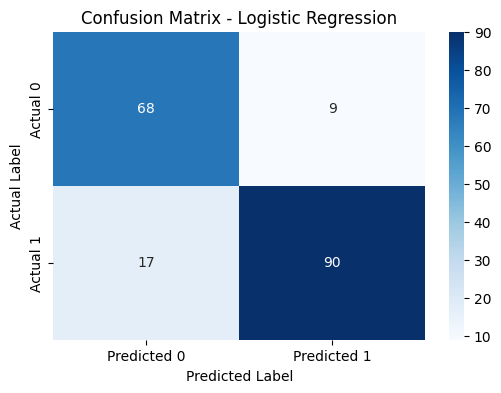

In [28]:
# Confusion Matrix

conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [29]:
# Cross-validation

cv_scores_log_reg = cross_val_score(log_reg_model, X, y, cv=5, scoring='accuracy') # 5-fold cross-validation
print("\nLogistic Regression Cross-Validation Scores (5-fold):")
print(cv_scores_log_reg)
print(f"Mean CV Accuracy: {cv_scores_log_reg.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores_log_reg.std():.4f}")


Logistic Regression Cross-Validation Scores (5-fold):
[0.90217391 0.85326087 0.8423913  0.86338798 0.74863388]
Mean CV Accuracy: 0.8420
Standard Deviation of CV Accuracy: 0.0508


### 2. Naive Bayes Classifier

Naive Bayes Model Evaluation:
Accuracy: 0.8478
Precision: 0.9158
Recall: 0.8131
F1-Score: 0.8614


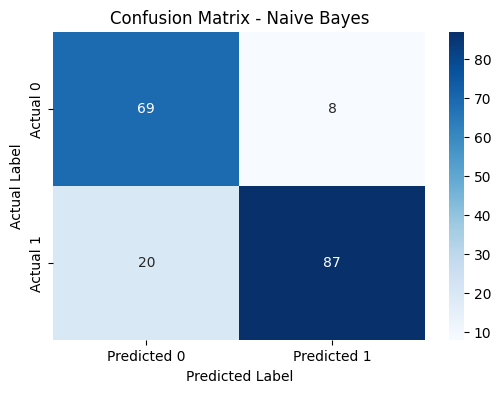


Naive Bayes Cross-Validation Scores (5-fold):
[0.86413043 0.8423913  0.84782609 0.83606557 0.78688525]
Mean CV Accuracy: 0.8355
Standard Deviation of CV Accuracy: 0.0260


In [25]:
from sklearn.naive_bayes import GaussianNB

# Initialize and train the Gaussian Naive Bayes model
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train, y_train)

# Make predictions
y_pred_naive_bayes = naive_bayes_model.predict(X_test)

# Evaluate the model
print("Naive Bayes Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_naive_bayes):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_naive_bayes):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_naive_bayes):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_naive_bayes):.4f}")

# Confusion Matrix
conf_matrix_naive_bayes = confusion_matrix(y_test, y_pred_naive_bayes)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_naive_bayes, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Naive Bayes')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Cross-validation
cv_scores_naive_bayes = cross_val_score(naive_bayes_model, X, y, cv=5) # 5-fold cross-validation
print("\nNaive Bayes Cross-Validation Scores (5-fold):")
print(cv_scores_naive_bayes)
print(f"Mean CV Accuracy: {cv_scores_naive_bayes.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores_naive_bayes.std():.4f}")

### 3. Decision Tree Classifier

Decision Tree Model Evaluation:
Accuracy: 0.7935
Precision: 0.8710
Recall: 0.7570
F1-Score: 0.8100


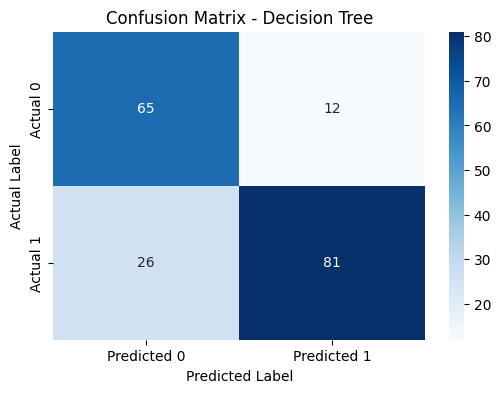


Decision Tree Cross-Validation Scores (5-fold):
[0.75543478 0.76630435 0.77173913 0.68852459 0.69398907]
Mean CV Accuracy: 0.7352
Standard Deviation of CV Accuracy: 0.0363


In [34]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree Classifier model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_decision_tree = decision_tree_model.predict(X_test)

# Evaluate the model
print("Decision Tree Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_decision_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_decision_tree):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_decision_tree):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_decision_tree):.4f}")

# Confusion Matrix
conf_matrix_decision_tree = confusion_matrix(y_test, y_pred_decision_tree)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_decision_tree, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Cross-validation
cv_scores_decision_tree = cross_val_score(decision_tree_model, X, y, cv=5) # 5-fold cross-validation
print("\nDecision Tree Cross-Validation Scores (5-fold):")
print(cv_scores_decision_tree)
print(f"Mean CV Accuracy: {cv_scores_decision_tree.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores_decision_tree.std():.4f}")

### 4. K-Nearest Neighbors (KNN) Classifier

K-Nearest Neighbors Model Evaluation:
Accuracy: 0.8370
Precision: 0.8812
Recall: 0.8318
F1-Score: 0.8558


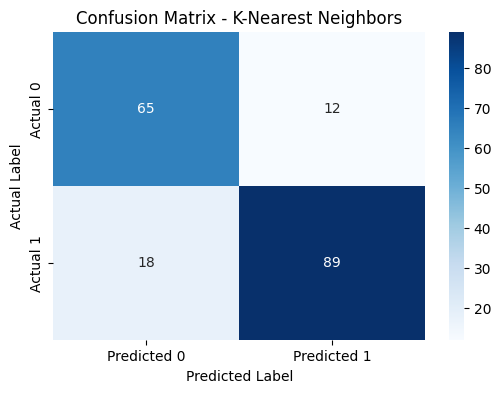


K-Nearest Neighbors Cross-Validation Scores (5-fold):
[0.875      0.82065217 0.82065217 0.81420765 0.75956284]
Mean CV Accuracy: 0.8180
Standard Deviation of CV Accuracy: 0.0366


In [35]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the KNN model
# A common practice is to start with k=5, or choose k based on domain knowledge or data characteristics.
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
print("K-Nearest Neighbors Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")

# Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - K-Nearest Neighbors')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Cross-validation
cv_scores_knn = cross_val_score(knn_model, X, y, cv=5) # 5-fold cross-validation
print("\nK-Nearest Neighbors Cross-Validation Scores (5-fold):")
print(cv_scores_knn)
print(f"Mean CV Accuracy: {cv_scores_knn.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores_knn.std():.4f}")

### 5. Support Vector Machine (SVM) Classifier

Support Vector Machine Model Evaluation:
Accuracy: 0.8478
Precision: 0.8762
Recall: 0.8598
F1-Score: 0.8679


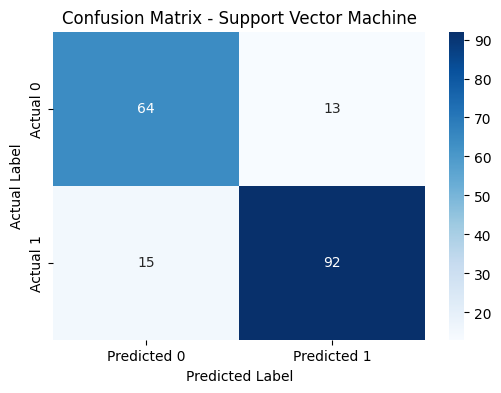


Support Vector Machine Cross-Validation Scores (5-fold):
[0.88043478 0.82608696 0.83695652 0.83060109 0.74863388]
Mean CV Accuracy: 0.8245
Standard Deviation of CV Accuracy: 0.0426


In [36]:
from sklearn.svm import SVC

# Initialize and train the SVM model
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
print("Support Vector Machine Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm):.4f}")

# Confusion Matrix
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Support Vector Machine')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Cross-validation
cv_scores_svm = cross_val_score(svm_model, X, y, cv=5) # 5-fold cross-validation
print("\nSupport Vector Machine Cross-Validation Scores (5-fold):")
print(cv_scores_svm)
print(f"Mean CV Accuracy: {cv_scores_svm.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores_svm.std():.4f}")

In [22]:
# Hyperparameter -
# manual search, grid search cv, randomized search cv

## Hyperparameter Tuning for SVM

Hyperparameter tuning is a critical step to optimize the performance of machine learning models. Two common strategies for hyperparameter tuning are `GridSearchCV` and `RandomizedSearchCV`.

### GridSearchCV
`GridSearchCV`  searches through a  subset of hyperparameters. For each combination, it trains and evaluates the model using cross-validation. While thorough, it can be computationally expensive for a large number of hyperparameters or a wide range of values.

### RandomizedSearchCV
`RandomizedSearchCV` samples a fixed number of hyperparameter settings from specified distributions. This can be more efficient than `GridSearchCV` when the search space is large, as it doesn't try every single combination but rather explores a random subset.

Let's use `GridSearchCV` to tune the `SVC` (Support Vector Classifier) model. We'll define a parameter grid for `C` (regularization parameter) and `kernel` type.

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best parameters found for SVM: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best cross-validation accuracy for SVM: 0.8610101574876527

Optimized SVM Model Evaluation (on Test Set):
Accuracy: 0.8478
Precision: 0.8762
Recall: 0.8598
F1-Score: 0.8679


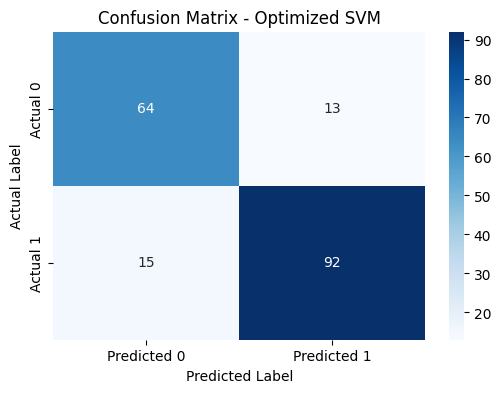

In [38]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], # Kernel type
    'gamma': ['scale', 'auto'] # Kernel coefficient for 'rbf', 'poly' and 'sigmoid'
}

# Initialize GridSearchCV
grid_search_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_svm.fit(X_train, y_train)

# Print the best parameters and best score
print("\nBest parameters found for SVM:", grid_search_svm.best_params_)
print("Best cross-validation accuracy for SVM:", grid_search_svm.best_score_)

# Get the best model
best_svm_model = grid_search_svm.best_estimator_

# Make predictions with the best model
y_pred_best_svm = best_svm_model.predict(X_test)

# Evaluate the best model on the test set
print("\nOptimized SVM Model Evaluation (on Test Set):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_svm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best_svm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best_svm):.4f}")

# Confusion Matrix for optimized SVM
conf_matrix_best_svm = confusion_matrix(y_test, y_pred_best_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_best_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Optimized SVM')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### RandomizedSearchCV for SVM

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found for SVM with RandomizedSearchCV: {'C': np.float64(0.17787658410143284), 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation accuracy for SVM with RandomizedSearchCV: 0.8541981176032056

Optimized SVM Model Evaluation (on Test Set) with RandomizedSearchCV:
Accuracy: 0.8641
Precision: 0.9100
Recall: 0.8505
F1-Score: 0.8792


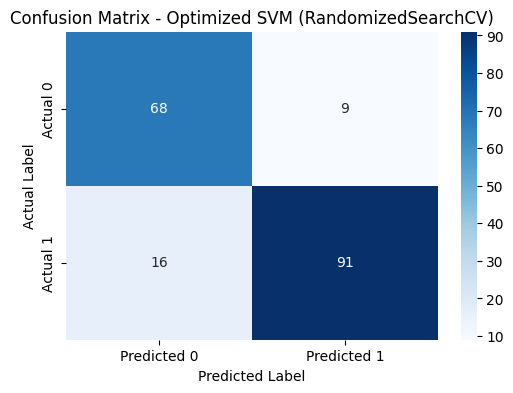

In [39]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the parameter distributions for SVM
param_dist_svm = {
    'C': uniform(loc=0.1, scale=100), # Continuous distribution from 0.1 to 100.1
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', uniform(loc=0.0001, scale=0.1)] # Can mix discrete and continuous
}

random_search_svm = RandomizedSearchCV(SVC(random_state=42), param_distributions=param_dist_svm,
                                       n_iter=50, cv=5, scoring='accuracy', n_jobs=-1, verbose=1, random_state=42)


random_search_svm.fit(X_train, y_train)

# Print the best parameters and best score
print("\nBest parameters found for SVM with RandomizedSearchCV:", random_search_svm.best_params_)
print("Best cross-validation accuracy for SVM with RandomizedSearchCV:", random_search_svm.best_score_)

# Get the best model from random search
best_svm_model_random = random_search_svm.best_estimator_

# Make predictions with the best model
y_pred_best_svm_random = best_svm_model_random.predict(X_test)

# Evaluate the best model on the test set
print("\nOptimized SVM Model Evaluation (on Test Set) with RandomizedSearchCV:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_svm_random):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_svm_random):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best_svm_random):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best_svm_random):.4f}")

# Confusion Matrix for optimized SVM from random search
conf_matrix_best_svm_random = confusion_matrix(y_test, y_pred_best_svm_random)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_best_svm_random, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Optimized SVM (RandomizedSearchCV)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()